# The Great American Coffee Taste Test — Predicting Daily Coffee Consumption
## STAT 301 — Individual Assignment 2

**Student:** Makafui Amouzouvi  
**Group:** 9 — Best Fits  
**Group Members:** Makafui Amouzouvi, Tiffany Nguyen, Nolan Bishop, Adam Cook  
**Dataset:** The Great American Coffee Taste Test (TidyTuesday, 2024-05-14)

In [123]:
# Load required libraries
library(tidyverse)
library(knitr)
library(broom)
library(glmnet)

---
## Part 1: Data Description

### Background

In October 2023, world-champion barista James Hoffmann and coffee company Cometeer hosted "The Great American Coffee Taste Test" as a YouTube livestream. Approximately 4,000 participants across the United States received four flash-frozen coffee samples and tasted them blind while following along with the stream. After tasting, participants completed a detailed online survey covering their demographics, coffee habits, and ratings for each of the four coffees. The data was subsequently made public by data blogger Robert McKeon Aloe and later published through the TidyTuesday project (week of May 14, 2024).

**Important caveat:** Because participation was voluntary and the audience consisted primarily of James Hoffmann's fanbase, the sample is not representative of the general American population.

**Citation:**  
McKeon Aloe, R. (2023). *Great American Coffee Taste Test Breakdown*. Medium. https://rmckeon.medium.com/great-american-coffee-taste-test-breakdown-7f3fdcc3c41d  
TidyTuesday (2024-05-14). https://github.com/rfordatascience/tidytuesday/blob/main/data/2024/2024-05-14/readme.md

### 1a. Load the Data & Dimensions

In [124]:
# Load data directly from GitHub (reproducible — no local files)
coffee_survey <- readr::read_csv(
  'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv',
  show_col_types = FALSE
)

cat("Number of observations:", nrow(coffee_survey), "\n")
cat("Number of variables:", ncol(coffee_survey), "\n")

Number of observations: 4042 
Number of variables: 57 


The dataset contains **4,042 observations** and **57 variables**, covering participant demographics, coffee consumption habits, and blind taste-test ratings for four coffees.

### 1b. Variable Names and Types

In [125]:
# Create a readable table of variable names and types
var_table <- tibble(
  Variable = names(coffee_survey),
  Type = sapply(coffee_survey, class)
)

kable(var_table, caption = "Table 1: Variable names and data types in the coffee_survey dataset")



Table: Table 1: Variable names and data types in the coffee_survey dataset

|Variable                     |Type      |
|:----------------------------|:---------|
|submission_id                |character |
|age                          |character |
|cups                         |character |
|where_drink                  |character |
|brew                         |character |
|brew_other                   |character |
|purchase                     |character |
|purchase_other               |character |
|favorite                     |character |
|favorite_specify             |character |
|additions                    |character |
|additions_other              |character |
|dairy                        |character |
|sweetener                    |character |
|style                        |character |
|strength                     |character |
|roast_level                  |character |
|caffeine                     |character |
|expertise                    |numeric   |
|coffee_a_bitternes

The dataset contains a mix of character variables (e.g., `age`, `favorite`, `brew`, `roast_level`) and numeric variables (e.g., `expertise`, `coffee_a_bitterness`, `coffee_a_personal_preference`). Most demographic and preference variables are stored as character strings.

### 1c. Data Collection

The data were collected via a voluntary online survey linked to a YouTube livestream event on October 21, 2023. Participants self-selected into the study by purchasing a Cometeer coffee kit in advance. Because the sample is self-selected and drawn from the audience of a specific content creator, we assume the data represent a **convenience sample** and may not generalize to all American coffee drinkers.

---
## Part 2: Research Question

### 2a. Question

> **Can we use demographic characteristics and coffee-drinking habits (such as age, self-reported coffee expertise, preferred roast level, and use of additions like milk or sugar) to predict the number of cups of coffee a person drinks per day?**

This question focuses on **prediction** with elements of **inference**: we want to identify which variables are most strongly associated with daily coffee consumption and build a model that could predict consumption count for new individuals. Since the response is a count variable (number of cups per day), this question is well-suited to **Poisson regression**, as required for our Group.

### 2b. Focus
This question focuses on **both prediction and inference**. We want to predict daily cup count, but we also want to understand *which* factors drive higher consumption.

### 2c. Response Variable
The response variable is `cups` — "How many cups of coffee do you typically drink per day?" — which is a count variable recorded as a character string (e.g., "1", "2", "3", "4", "More than 4") and will need to be converted to numeric for Poisson modeling.

### 2d. Key Anticipated Covariates
- **`expertise`** (numeric, 1–10 self-rated): people who consider themselves coffee experts may drink more.
- **`age`** (categorical): consumption habits likely vary across age groups.
- **`roast_level`** (categorical): preference for stronger roasts may correlate with higher consumption.
- **`strength`** (categorical): preferred coffee strength is likely directly related to quantity consumed.
- **`caffeine`** (categorical): those who care about caffeine may consume more cups.

### 2e. Role of Other Variables
Variables such as `employment_status`, and `work_from_home` may act as **confounders** — for example, people who work from home may have easier access to coffee and thus drink more. Taste-test rating variables (`coffee_a_personal_preference`, etc.) are less likely to be relevant to daily cup count but could be included as supplementary controls.

---
## Part 3: Exploratory Data Analysis and Visualization

### 3a. Load, Clean, and Wrangle Data

For this analysis, and the rest of the project, responses of "More than 4" cups are coded as 5, treating all consumption above 4 cups as equivalent. This decision was made because the survey does not capture the exact value for high consumers. 

In [126]:
# Clean and wrangle into tidy format
coffee_clean <- coffee_survey |>
  # Convert cups to numeric (treat "More than 4" as 5)
  mutate(
    cups_numeric = case_when(
      cups == "Less than 1" ~ 0,
      cups == "1"           ~ 1,
      cups == "2"           ~ 2,
      cups == "3"           ~ 3,
      cups == "4"           ~ 4,
      cups == "More than 4" ~ 5,
      TRUE                  ~ NA_real_
    ),
    # Clean age groups
    age = factor(age, levels = c("<18 years old", "18-24 years old",
                                  "25-34 years old", "35-44 years old",
                                  "45-54 years old", "55-64 years old",
                                  ">65 years old")),
    # Clean roast level
    roast_level = factor(roast_level, levels = c("Light", "Medium", "Dark",
                                                   "I don't know")),
    # Clean strength
    strength = factor(strength, levels = c("Weak", "Somewhat light", "Medium",
                                            "Somewhat strong", "Very strong"))
  ) |>
  # Remove rows with missing response
  filter(!is.na(cups_numeric))

cat("Rows after cleaning:", nrow(coffee_clean), "\n")
glimpse(coffee_clean |> select(cups_numeric, age, roast_level, strength, expertise))

Rows after cleaning: 3949 
Rows: 3,949
Columns: 5
$ cups_numeric <dbl> 0, 2, 1, 3, 3, 1, 2, 2, 3, 5, 1, 2, 1, 3, 1, 2, 3, 2, 3, …
$ age          <fct> 25-34 years old, <18 years old, 25-34 years old, <18 year…
$ roast_level  <fct> NA, Light, Light, Light, NA, Medium, NA, NA, NA, NA, Ligh…
$ strength     <fct> NA, Somewhat light, Somewhat strong, Medium, Somewhat str…
$ expertise    <dbl> NA, NA, 7, 10, 7, 6, NA, 4, NA, 8, 5, 7, 7, NA, 7, NA, NA…


### 3b. Missing Values

In [127]:
# Count missing values and proportion for each variable
missing_summary <- coffee_survey |>
  summarise(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "Variable", values_to = "Missing_Count") |>
  mutate(
    Total = nrow(coffee_survey),
    Proportion_Missing = round(Missing_Count / Total, 3),
    High_Missing = if_else(Proportion_Missing > 0.20, "Yes", "No")
  ) |>
  arrange(desc(Proportion_Missing))

# Show top 20 variables with the most missing data
kable(
  head(missing_summary, 20),
  caption = "Table 2: Top 20 variables by proportion of missing values"
)



Table: Table 2: Top 20 variables by proportion of missing values

|Variable               | Missing_Count| Total| Proportion_Missing|High_Missing |
|:----------------------|-------------:|-----:|------------------:|:------------|
|gender_specify         |          4030|  4042|              0.997|Yes          |
|purchase_other         |          4011|  4042|              0.992|Yes          |
|additions_other        |          3994|  4042|              0.988|Yes          |
|ethnicity_race_specify |          3937|  4042|              0.974|Yes          |
|favorite_specify       |          3926|  4042|              0.971|Yes          |
|why_drink_other        |          3875|  4042|              0.959|Yes          |
|sweetener              |          3530|  4042|              0.873|Yes          |
|brew_other             |          3364|  4042|              0.832|Yes          |
|purchase               |          3332|  4042|              0.824|Yes          |
|dairy                  |     

In [128]:
# Variables with > 20% missing
high_missing <- missing_summary |> filter(High_Missing == "Yes")
cat("Variables with > 20% missing data:", nrow(high_missing), "\n")
print(high_missing |> select(Variable, Proportion_Missing))

Variables with > 20% missing data: 14 
# A tibble: 14 × 2
   Variable               Proportion_Missing
   <chr>                               <dbl>
 1 gender_specify                      0.997
 2 purchase_other                      0.992
 3 additions_other                     0.988
 4 ethnicity_race_specify              0.974
 5 favorite_specify                    0.971
 6 why_drink_other                     0.959
 7 sweetener                           0.873
 8 brew_other                          0.832
 9 purchase                            0.824
10 dairy                               0.583
11 coffee_c_notes                      0.41 
12 coffee_b_notes                      0.392
13 coffee_a_notes                      0.362
14 coffee_d_notes                      0.36 


Several variables have more than 20% missing values, particularly `sweetener`, `dairy`, `purchase`, `brew_other`, and some open-text fields. These variables with many missing values likely reflect that only participants who selected certain options (e.g., those who add dairy) were prompted to answer follow-up questions. The key variables for our question (`cups`, `age`, `roast_level`, `strength`, `expertise`) have relatively low rates of missing values.

### 3c. Class Imbalance in Categorical Variables

In [129]:
# Check class imbalance in key categorical variables
cat("--- Roast Level ---\n")
print(coffee_clean |> count(roast_level) |> mutate(prop = round(n / sum(n), 3)))

cat("\n--- Cups per Day ---\n")
print(coffee_clean |> count(cups) |> mutate(prop = round(n / sum(n), 3)))

cat("\n--- Age Group ---\n")
print(coffee_clean |> count(age) |> mutate(prop = round(n / sum(n), 3)))

--- Roast Level ---
# A tibble: 4 × 3
  roast_level     n  prop
  <fct>       <int> <dbl>
1 Light        1759 0.445
2 Medium       1536 0.389
3 Dark          403 0.102
4 NA            251 0.064

--- Cups per Day ---
# A tibble: 6 × 3
  cups            n  prop
  <chr>       <int> <dbl>
1 1            1277 0.323
2 2            1663 0.421
3 3             473 0.12 
4 4             121 0.031
5 Less than 1   348 0.088
6 More than 4    67 0.017

--- Age Group ---
# A tibble: 8 × 3
  age                 n  prop
  <fct>           <int> <dbl>
1 <18 years old      19 0.005
2 18-24 years old   447 0.113
3 25-34 years old  1956 0.495
4 35-44 years old   948 0.24 
5 45-54 years old   296 0.075
6 55-64 years old   182 0.046
7 >65 years old      94 0.024
8 NA                  7 0.002


There is evidence of class imbalance in `age`: the 25–34 and 35–44 year-old groups dominate the sample, reflecting the demographic of James Hoffmann's YouTube audience. For `roast_level`, medium and light roasts together account for the vast majority of preferences. The `cups` variable shows that most respondents drink 2–3 cups per day, with very few drinking 0 or more than 4.

### 3d. Visualization

The plot below explores the relationship between **daily coffee consumption** (our Poisson response), **age group**, and **preferred roast level**, with point/bar color encoding self-reported **coffee expertise**. This directly addresses our research question by showing whether demographic groups and roast preferences are associated with drinking more cups per day.

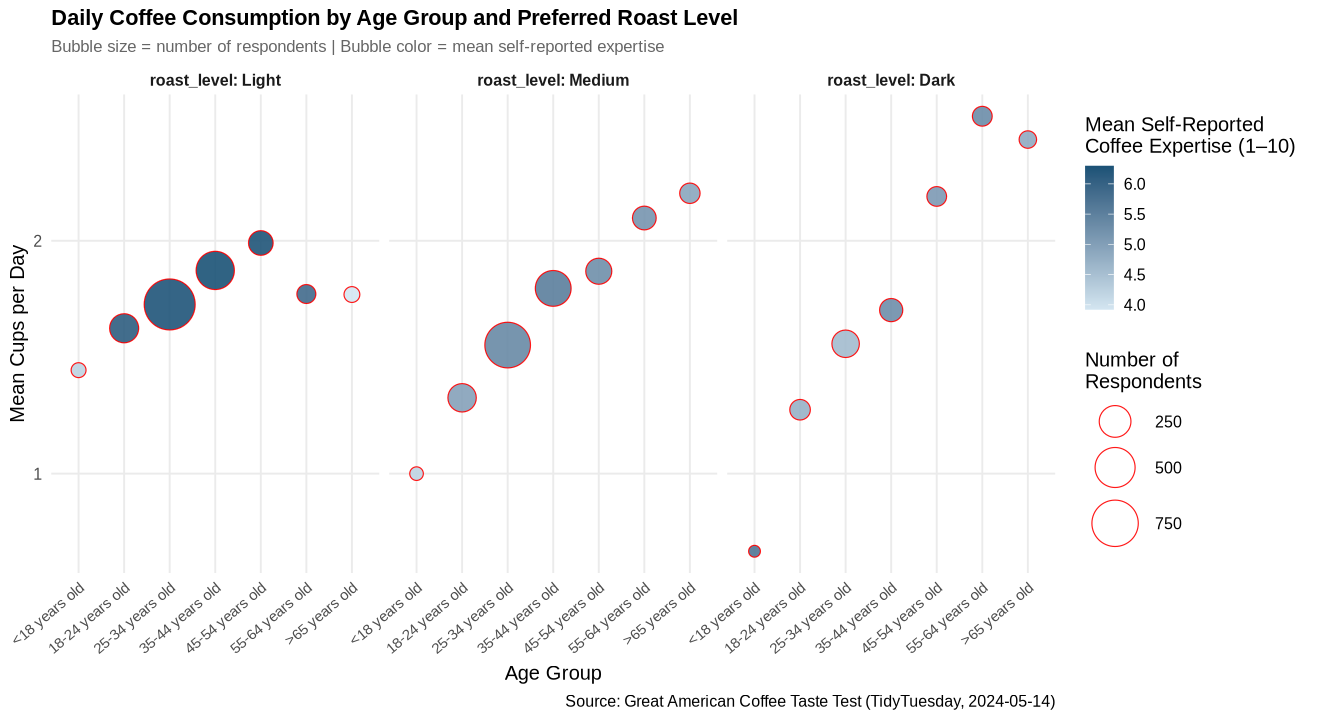

In [130]:
options(repr.plot.width = 11, repr.plot.height = 6)

# Summarise: mean cups and mean expertise by age + roast_level
plot_data <- coffee_clean |>
  filter(!is.na(age), !is.na(roast_level), roast_level != "I don't know",
         !is.na(expertise)) |>
  group_by(age, roast_level) |>
  summarise(
    mean_cups = mean(cups_numeric, na.rm = TRUE),
    mean_expertise = mean(expertise, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

plot <- ggplot(plot_data, aes(x = age, y = mean_cups, fill = mean_expertise, size = n)) +
  geom_point(shape = 21, color = "red", stroke = 0.5, alpha = 0.9) +
  facet_wrap(~ roast_level, nrow = 1, labeller = label_both) +
  scale_fill_gradient(low = "#d4e6f1", high = "#1a5276",
                      name = "Mean Self-Reported\nCoffee Expertise (1–10)") +
  scale_size_continuous(range = c(3, 14), name = "Number of\nRespondents") +
  scale_y_continuous(breaks = 1:5,
                     labels = c("1", "2", "3", "4", "4+")) +
  labs(
    title = "Daily Coffee Consumption by Age Group and Preferred Roast Level",
    subtitle = "Bubble size = number of respondents | Bubble color = mean self-reported expertise",
    x = "Age Group",
    y = "Mean Cups per Day",
    caption = "Source: Great American Coffee Taste Test (TidyTuesday, 2024-05-14)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 40, hjust = 1, size = 9),
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "grey40", size = 10),
    legend.position = "right",
    panel.grid.minor = element_blank()
  )
print(plot)

**Interpretation:**  
This bubble chart displays the average number of cups consumed per day across age groups (x-axis), faceted by preferred roast level. Each bubble encodes two additional variables: its **color** represents the mean self-reported coffee expertise of that group (darker blue = more expert), and its **size** represents the number of respondents. 

Key observations:
- Older age groups (45+) drink on average notably more cups per day across all roast levels, with the 55–64 and >65 groups consistently appearing at the top of the y-axis, particularly for Dark roast.

- Light roast has the largest bubbles overall (especially 25–44 year olds), indicating it is the most popular roast preference in this sample. Yet these groups do not drink the most cups per day.
- Dark roast drinkers in older age groups (45+) show the highest mean daily consumption, suggesting an interaction between age and roast preference worth exploring in the Poisson model.
- Light roast drinkers report notably higher coffee expertise (darker blue bubbles) compared to Medium and Dark roast drinkers, whose bubbles are consistently lighter. This may suggest that self-identified coffee experts tend to prefer lighter roasts.
- The <18 age group has very small bubbles across all roast levels, reflecting very few respondents, making those estimates unreliable.

This plot is directly relevant to our research question because it simultaneously visualizes the relationship between three key covariates (age, roast preference, and expertise) and our Poisson response (mean cups per day), revealing patterns that suggest age and roast level may be important predictors in the Poisson model.

---
## Section 1: Methods and Plan

### 1a. Reviewed Question

> **Can we use demographic characteristics and coffee-drinking habits (age, self-reported coffee expertise, preferred roast level, and preferred strength) to predict the number of cups of coffee a person drinks per day?**

The question remains focused on **prediction**: whether a set of demographic and habit variables can meaningfully predict daily coffee consumption for new individuals. Because the data come from a voluntary survey (observational study), we cannot make causal claims. The question is framed strictly in terms of *prediction*.

### 1b. Proposed Method: LASSO-Poisson Regression

This is what I intend to do :

1. **LASSO Poisson regression** (via `glmnet`) with cross-validation on the training set to perform variable selection from a candidate set of 8 predictors selected based on domain knowledge. 
2. **Refit a standard Poisson GLM** using only the variables whose LASSO coefficients are non-zero at `lambda.min`, then generate predictions on the held-out test set.

**Candidate predictors and rationale:**

| Variable | Rationale |
|---|---|
| `age` | Demographic characteristic: consumption habits may vary across life stages |
| `expertise` | Self-reported coffee knowledge may drive higher consumption |
| `roast_level` | Preference: stronger roasts may correlate with more cups |
| `strength` | Preferred intensity likely related to quantity consumed |
| `caffeine` | Motivation for drinking coffee |
| `work_from_home` | Affects access and opportunity to drink coffee |
| `employment_status` | Lifestyle factor that may influence daily routine |
| `taste` | General coffee enjoyment may predict habitual consumption |

**Why LASSO + Poisson?**

- The response is a non-negative integer **count**, making Poisson regression the appropriate distributional choice over linear regression.
- With 8 candidate predictors (several of which are multi-level categorical variables expanding into many dummy columns), LASSO regularization provides principled, data-driven variable selection. Shrinking coefficients of weak predictors to exactly zero.
- Using `lambda.min` from cross-validation minimizes prediction error on held-out folds, directly optimizing for our predictive goal.
- The 80/20 train/test split ensures predictive performance is evaluated on truly unseen data.

### 1c. Assumptions and Limitations

**Assumptions:**

1. **Count response:** Poisson regression assumes a non-negative integer response. `cups_numeric` satisfies this, though coding "More than 4" as 5 may introduce measurement error in the upper tail since the true value is unknown.

2. **Equidispersion (mean = variance):** Poisson regression assumes the conditional mean equals the conditional variance. Overdispersion (variance > mean) is common in count data and could cause underestimated standard errors. We check this via the dispersion ratio.

3. **Independence of observations:** Each respondent's cup count is assumed independent. This is approximately satisfied since participants are unrelated individuals, though all are drawn from the same event audience.

4. **LASSO assumes a sparse true model:** LASSO performs best when only a subset of predictors truly influence the response. If many predictors have small but non-zero effects, LASSO may over-shrink and discard useful variables.

**Limitations:**

- **Multicollinearity:** Predictors like `strength` and `expertise` may be correlated. LASSO handles multicollinearity better than ordinary regression by selecting one variable from a correlated group, but this means some informative predictors may be dropped arbitrarily.
- **Categorical encoding:** Multi-level categorical variables (e.g., `age` with 7 levels) expand into many dummy columns. LASSO treats each dummy independently, which can lead to partial selection of a factor (e.g., keeping some age levels but not others).
- **Confounding and observational data:** Causal interpretation is not possible. Variables like `work_from_home` may proxy for unmeasured confounders (e.g., job type, income).
- **Non-representative sample:** The convenience sample limits generalizability beyond the population of engaged coffee enthusiasts following James Hoffmann's content.

---
## Section 2: Computational Code and Output

### 2a. Data Preparation, Train/Test Split, and LASSO Variable Selection

#### *2a.1. Prepare modelling dataset with all 9 candidate predictors*

In [131]:
# Prepare modelling dataset with all 9 candidate predictors

coffee_clean <- coffee_clean |>
  mutate(
    caffeine          = factor(caffeine),
    taste             = factor(taste),
    work_from_home    = factor(wfh),
    employment_status = factor(employment_status)
  ) |>
  filter(
    !is.na(cups_numeric),
    !is.na(age),
    !is.na(expertise),
    !is.na(roast_level), roast_level != "I don't know",
    !is.na(strength),
    !is.na(gender),
    !is.na(caffeine),
    !is.na(taste),
    !is.na(wfh),
    !is.na(employment_status)
  )

cat("Observations after filtering:", nrow(coffee_model), "\n")
head(coffee_clean, 3)

Observations after filtering: 3173 


submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,⋯,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation,cups_numeric,work_from_home
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<dbl>,<fct>
ylqbBg,45-54 years old,2,"At home, At the office, At a cafe, On the go","Pour over, French press, Espresso",NA,"Local cafe, Specialty coffee shop",NA,Regular drip coffee,NA,⋯,Male,NA,Master's degree,Other (please specify),Mix,Employed full-time,2,No affiliation,2,I primarily work from home
YZzBdN,25-34 years old,2,"At home, At the office","Pour over, Espresso",NA,NA,NA,Pourover,NA,⋯,Male,NA,Master's degree,Asian/Pacific Islander,NA,Unemployed,None,Independent,2,I do a mix of both
VZ17Z6,35-44 years old,1,"At the office, At home",Pour over,NA,NA,NA,Iced coffee,NA,⋯,Male,NA,Bachelor's degree,White/Caucasian,NA,Employed full-time,3,No affiliation,1,I primarily work in person


#### *2a.2. Making the train and test data*

In [132]:
# 80/20 train/test split
set.seed(301)
n          <- nrow(coffee_model)
train_idx  <- sample(seq_len(n), size = floor(0.8 * n))
train_data <- coffee_model[train_idx, ]
test_data  <- coffee_model[-train_idx, ]

cat("Training observations:", nrow(train_data), "\n")
cat("Test observations:    ", nrow(test_data),  "\n")

# Build model matrix (dummy-encode all categorical predictors)
predictors <- c("age", "expertise", "roast_level", "strength",
                "caffeine", "work_from_home",
                "employment_status", "taste")

X_train <- model.matrix(~ . - 1,  data = train_data[, predictors])
X_test  <- model.matrix(~ . - 1,  data = test_data[,  predictors])
y_train <- train_data$cups_numeric
y_test  <- test_data$cups_numeric

cat("X_train after building model matrix below:")
head(X_train,3)

Training observations: 2538 
Test observations:     635 
X_train after building model matrix below:

,age<18 years old,age18-24 years old,age25-34 years old,age35-44 years old,age45-54 years old,age55-64 years old,age>65 years old,expertise,roast_levelMedium,roast_levelDark,⋯,caffeineFull caffeine,caffeineHalf caff,work_from_homeI primarily work from home,work_from_homeI primarily work in person,employment_statusEmployed part-time,employment_statusHomemaker,employment_statusRetired,employment_statusStudent,employment_statusUnemployed,tasteYes
1,0,0,0,1,0,0,0,7,0,0,⋯,1,0,1,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0,7,0,0,⋯,1,0,0,1,0,0,0,0,0,1
3,0,0,1,0,0,0,0,9,0,0,⋯,1,0,0,0,0,0,0,1,0,1


#### *2a.3. LASSO Poisson with 10-fold CV to find lambda.min*

In [133]:
# LASSO Poisson with 10-fold CV to find lambda.min
set.seed(301)
lasso_cv <- cv.glmnet(
  X_train, y_train,
  family  = "poisson",
  alpha   = 1,
  nfolds  = 10
)

cat("\nlambda.min:", round(lasso_cv$lambda.min, 5), "\n")

# Extract non-zero coefficients at lambda.min
lasso_coefs <- coef(lasso_cv, s = "lambda.min")
selected_predictors <- rownames(lasso_coefs)[lasso_coefs[, 1] != 0]
selected_predictors <- selected_predictors[selected_predictors != "(Intercept)"]
cat("Variables selected by LASSO:", length(selected_predictors), "\n")
print(selected_predictors)


lambda.min: 0.00404 
Variables selected by LASSO: 20 
 [1] "age<18 years old"                        
 [2] "age18-24 years old"                      
 [3] "age25-34 years old"                      
 [4] "age45-54 years old"                      
 [5] "age55-64 years old"                      
 [6] "age>65 years old"                        
 [7] "expertise"                               
 [8] "roast_levelMedium"                       
 [9] "strengthSomewhat light"                  
[10] "strengthSomewhat strong"                 
[11] "strengthVery strong"                     
[12] "caffeineFull caffeine"                   
[13] "caffeineHalf caff"                       
[14] "work_from_homeI primarily work from home"
[15] "work_from_homeI primarily work in person"
[16] "employment_statusEmployed part-time"     
[17] "employment_statusHomemaker"              
[18] "employment_statusRetired"                
[19] "employment_statusUnemployed"             
[20] "tasteYes"                  

### 2b. Refitting standard Poisson GLM using LASSO-selected predictors

#### *2b.1. Build formula and matrices*

In [134]:
# Refitting standard Poisson GLM using LASSO-selected predictors
# Build formula from selected dummy column names
refit_formula <- as.formula(
  paste("cups_numeric ~", paste(paste0("`", selected, "`"), collapse = " + "))
)

# Combine X matrices with response for glm()
train_df <- as.data.frame(X_train)
train_df$cups_numeric <- y_train
test_df  <- as.data.frame(X_test)
test_df$cups_numeric  <- y_test

#### *2b.2.Refitting standard Poisson GLM*

In [135]:
poisson_refit <- glm(
  refit_formula,
  data   = train_df,
  family = "poisson")

# Over/Under dispersion parameter
cat("Dispersion ratio:",
    round(deviance(poisson_refit) / df.residual(poisson_refit), 3), "\n")

Dispersion ratio: 0.533 


#### *2b.3.Predicting on test data*

In [136]:
# Predict on test set
test_df <- test_df |>
  mutate(
    predicted = predict(poisson_refit, newdata = test_df, type = "response"),
    actual    = cups_numeric
  )

rmse <- sqrt(mean((test_df$predicted - test_df$actual)^2))
null_rmse <- sqrt(mean((mean(y_train) - y_test)^2))
cat("Test RMSE:", round(rmse, 3), "\n")
cat("Null RMSE:", round(null_rmse, 3), "\n")

Test RMSE: 0.891 
Null RMSE: 0.968 


#### *2b.4.Prediction vs actual observations plot*

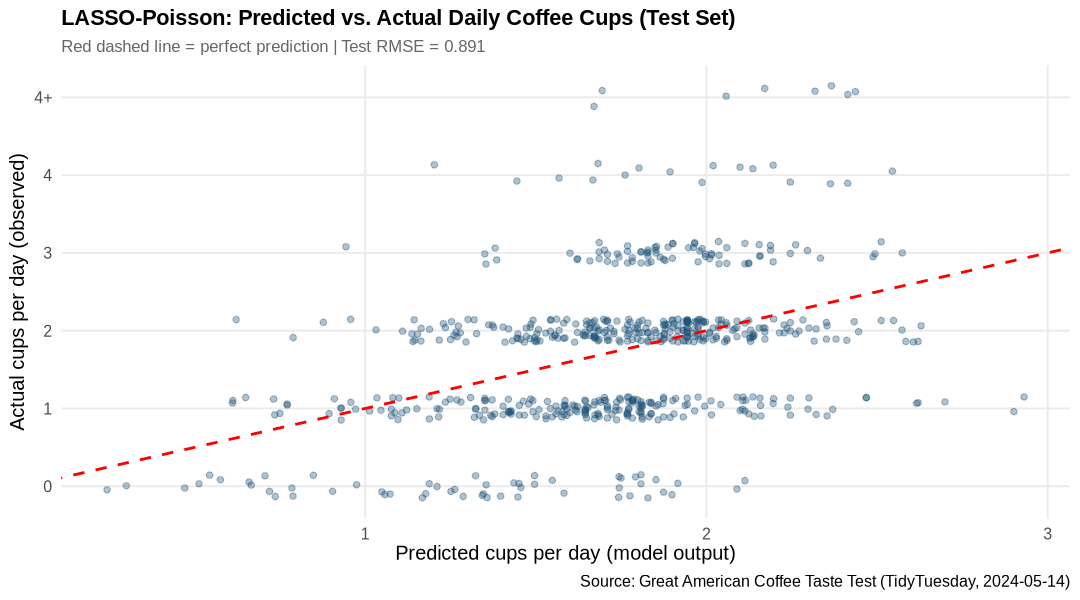

In [137]:
# Predicted vs. actual plot
options(repr.plot.width = 9, repr.plot.height = 5)

ggplot(test_df, aes(x = predicted, y = actual)) +
  geom_jitter(width = 0, height = 0.15, alpha = 0.35,
              color = "#1a5276", size = 1.5) +
  geom_abline(slope = 1, intercept = 0, color = "red",
              linewidth = 0.8, linetype = "dashed") +
  scale_y_continuous(breaks = 0:5,
                     labels = c("0","1","2","3","4","4+")) +
  labs(
    title    = "LASSO-Poisson: Predicted vs. Actual Daily Coffee Cups (Test Set)",
    subtitle = paste0("Red dashed line = perfect prediction | Test RMSE = ",
                      round(rmse, 3)),
    x        = "Predicted cups per day (model output)",
    y        = "Actual cups per day (observed)",
    caption  = "Source: Great American Coffee Taste Test (TidyTuesday, 2024-05-14)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(color = "grey40", size = 10),
    panel.grid.minor = element_blank()
  )

#### Interpretation of results. 

I used LASSO with 10-fold cross-validation at `lambda.min`, which selected 20 non-zero coefficients from the expanded candidate set, indicating that not all demographic and habit variables contribute equally to predicting daily coffee consumption. 

The refitted Poisson GLM achieved a test RMSE of 0.891 compared to a null RMSE of 0.968 *(only an 8% improvement over simply predicting the mean)*, suggesting the selected predictors add limited predictive signal relative to the narrow response range of 0–5 cups. 

The dispersion ratio of 0.533 indicates mild underdispersion, though since our goal is prediction rather than inference, this does not invalidate the RMSE or predicted values. The model likely misses unmeasured factors such as work schedule or caffeine sensitivity that drive more extreme consumption patterns.

### 3e. AI Tool Disclosure

Claude (Anthropic) was used as a support tool to help structure this notebook and suggest appropriate plotting functions.